In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [2]:
master = pd.read_csv(
    "../data/processed/se3_master_dataset.csv",
    parse_dates=["timestamp"]
)

train = master[
    (master["split"] == "train") &
    (master["price"].notna())
].copy()

train.shape

(8668, 22)

In [3]:
monthly_medians = train.groupby("month")["price"].median()

monthly_medians

month
1     36.540
2     54.790
3     44.290
4     47.970
5     12.730
6     25.350
7     20.580
8      5.000
9      9.555
10    13.270
11    47.770
12    29.130
Name: price, dtype: float64

In [4]:
train["anomaly_score"] = pd.NA
train["high_price_anomaly"] = False

monthly_models = {}

In [ ]:
for month in range(1, 13):

    mask = train["month"] == month

    X_month = train.loc[
        mask,
        ["price", "hour"]
    ]

    model = IsolationForest(
        n_estimators=100,
        contamination=0.01,
        random_state=42
    )
    

    model.fit(X_month)

    train.loc[mask, "anomaly_score"] = -model.score_samples(X_month)

    train.loc[mask, "is_anomaly"] = (
        model.predict(X_month) == -1
    )

    monthly_models[month] = model

In [ ]:
monthly_medians = train.groupby("month")["price"].transform("median")

train["high_price_anomaly"] = (
    train["is_anomaly"] &
    (train["price"] > monthly_medians)
)

In [7]:
train.groupby("month")["high_price_anomaly"].agg(
    total="size",
    high_anomalies="sum"
)

,total,high_anomalies
month,,
1,737,8
2,669,6
3,741,8
4,711,6
5,737,8
6,714,6
7,733,0
8,723,0
9,710,8


In [8]:
train[train["high_price_anomaly"]].groupby("month")["price"].agg(
    ["count", "min", "median", "max"]
)

,count,min,median,max
month,,,,
1,8,225.96,290.075,393.38
2,6,220.37,254.440,291.93
3,8,111.95,123.910,172.15
4,6,151.45,164.970,181.26
5,8,85.85,117.490,134.42
6,6,104.71,121.315,134.97
9,8,90.00,107.910,124.47
10,8,123.05,149.300,229.35
11,8,164.22,202.445,250.52


In [9]:
validation = master[
    (master["split"] == "validation") &
    (master["price"].notna())
].copy()

validation["anomaly_score"] = pd.NA
validation["is_anomaly"] = False
validation["high_price_anomaly"] = False

In [11]:
for month in sorted(validation["month"].unique()):

    mask = validation["month"] == month

    X_month = validation.loc[
        mask,
        ["price", "hour"]
    ]

    model = monthly_models[month]

    validation.loc[mask, "anomaly_score"] = (
        -model.score_samples(X_month)
    )

    validation.loc[mask, "is_anomaly"] = (
        model.predict(X_month) == -1
    )

    validation.loc[mask, "high_price_anomaly"] = (
        validation.loc[mask, "is_anomaly"] &
        (
            validation.loc[mask, "price"] >
            monthly_median_values.loc[month]
        )
    )

In [12]:
validation.groupby("month")["high_price_anomaly"].agg(
    total="size",
    high_anomalies="sum"
)

,total,high_anomalies
month,,
3,572,111
4,719,8
5,2,0


In [13]:
print("TRAIN March:")
print(
    train[train["month"] == 3]["price"].describe()
)

print("\nVALIDATION March:")
print(
    validation[validation["month"] == 3]["price"].describe()
)

TRAIN March:
count    741.000000
mean      42.497989
std       25.266771
min       -1.300000
25%       26.940000
50%       44.290000
75%       58.550000
max      172.150000
Name: price, dtype: float64

VALIDATION March:
count    572.000000
mean      55.978217
std       51.177287
min      -11.340000
25%       18.745000
50%       32.040000
75%       94.375000
max      257.050000
Name: price, dtype: float64


In [14]:
validation[
    (validation["month"] == 3) &
    (validation["high_price_anomaly"])
][
    ["timestamp", "price", "hour", "anomaly_score"]
].sort_values("timestamp")

,timestamp,price,hour,anomaly_score
8801,2025-03-09 17:00:00+00:00,128.53,18,0.666386
8802,2025-03-09 18:00:00+00:00,123.46,19,0.657362
8813,2025-03-10 05:00:00+00:00,154.79,6,0.707024
8814,2025-03-10 06:00:00+00:00,166.16,7,0.711654
8815,2025-03-10 07:00:00+00:00,138.18,8,0.682289
...,...,...,...,...
9319,2025-03-31 07:00:00+00:00,115.16,9,0.653821
9328,2025-03-31 16:00:00+00:00,115.22,18,0.6472
9329,2025-03-31 17:00:00+00:00,162.59,19,0.723898
9330,2025-03-31 18:00:00+00:00,150.56,20,0.724558


In [18]:
march_anomalies = validation[
    (validation["month"] == 3) &
    (validation["high_price_anomaly"])
].copy()

march_anomalies["date"] = (
    march_anomalies["timestamp"]
    .dt.tz_convert("Europe/Stockholm")
    .dt.date
)

march_anomalies.groupby("date").size()

date
2025-03-09     2
2025-03-10     7
2025-03-11    13
2025-03-12    13
2025-03-13    16
2025-03-14    12
2025-03-17     7
2025-03-18     2
2025-03-19     3
2025-03-20    10
2025-03-21     7
2025-03-24     4
2025-03-25     3
2025-03-26     5
2025-03-31     7
dtype: int64

In [19]:
march_anomalies["date"].nunique()

15

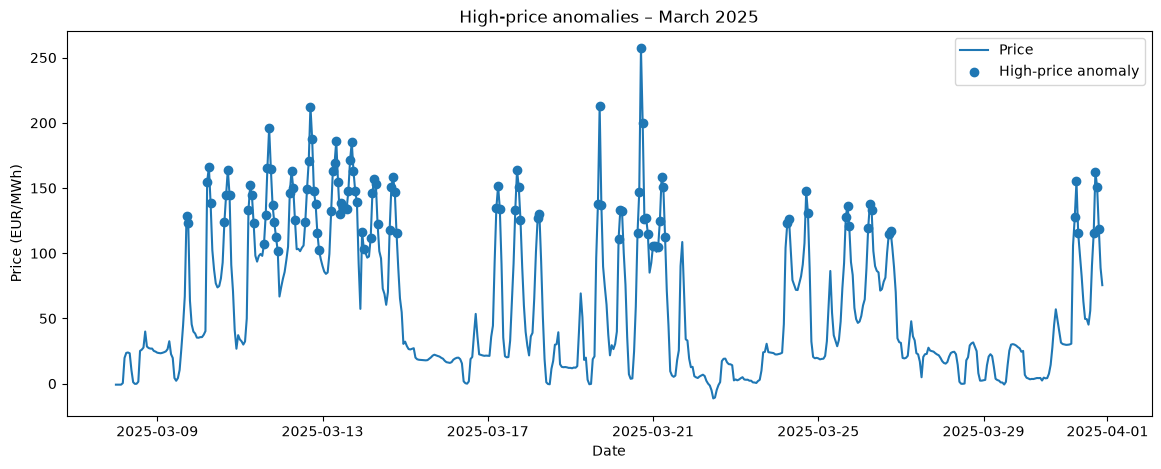

In [24]:
march_validation = validation[validation["month"] == 3]

plt.figure(figsize=(14, 5))

plt.plot(
    march_validation["timestamp"],
    march_validation["price"],
    label="Price"
)

anoms = march_validation[
    march_validation["high_price_anomaly"]
]

plt.scatter(
    anoms["timestamp"],
    anoms["price"],
    label="High-price anomaly"
)

plt.xlabel("Date")
plt.ylabel("Price (EUR/MWh)")
plt.title("High-price anomalies – March 2025")
plt.legend()
plt.show()

In [25]:
test = master[
    (master["split"] == "test") &
    (master["price"].notna())
].copy()

test["anomaly_score"] = pd.NA
test["is_anomaly"] = False
test["high_price_anomaly"] = False

In [26]:
for month in sorted(test["month"].unique()):

    mask = test["month"] == month

    X_month = test.loc[
        mask,
        ["price", "hour"]
    ]

    model = monthly_models[month]

    test.loc[mask, "anomaly_score"] = (
        -model.score_samples(X_month)
    )

    test.loc[mask, "is_anomaly"] = (
        model.predict(X_month) == -1
    )

    test.loc[mask, "high_price_anomaly"] = (
        test.loc[mask, "is_anomaly"] &
        (
            test.loc[mask, "price"] >
            monthly_median_values.loc[month]
        )
    )

In [27]:
test.groupby("month")["high_price_anomaly"].agg(
    total="size",
    high_anomalies="sum"
)

,total,high_anomalies
month,,
1,731,5
2,664,16
3,721,51
4,698,7
5,741,53
6,717,1
7,743,22
8,743,50
9,718,107


In [28]:
anomaly_labels = pd.concat([
    train[["timestamp", "anomaly_score", "high_price_anomaly"]],
    validation[["timestamp", "anomaly_score", "high_price_anomaly"]],
    test[["timestamp", "anomaly_score", "high_price_anomaly"]]
]).sort_values("timestamp")

In [29]:
anomaly_labels = pd.concat([
    train[["timestamp", "anomaly_score", "high_price_anomaly"]],
    validation[["timestamp", "anomaly_score", "high_price_anomaly"]],
    test[["timestamp", "anomaly_score", "high_price_anomaly"]]
]).sort_values("timestamp")
anomaly_labels.to_csv(
    "../data/processed/se3_anomaly_labels.csv",
    index=False
)